LOGISTIC REGRESSION

In [7]:
#Q1 IMIPLEMENT LOGISTIC REGREESION ON A DATASET HAVING THREE FEATURES F1,F2 AND TARGET
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data=pd.DataFrame({
    'F1':[1,2,3,4,5,6,7,8,9],
    'F2':[10,20,30,40,50,60,70,80,90],
    'Target':[0,0,0,0,1,1,1,1,1]
})

x=data[['F1','F2']]
y=data['Target']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print("Model Evaluation:")
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))





Model Evaluation:
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
 [[1 0]
 [0 1]]


# Q 2: IMPLEMENT L-R ON DATASET FROM SKLEARN LIBRARY(i.e DIABETES)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.datasets import load_diabetes

diabetes_data=load_diabetes()
x=diabetes_data.data
y=diabetes_data.target

y_binary=(y>np.mean(y)).astype(int)

X_train,X_test,y_train,y_test=train_test_split(x,y_binary,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=LogisticRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Model Evaluation:")
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))




Model Evaluation:
Accuracy: 0.7191011235955056

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.82      0.77        50
           1       0.72      0.59      0.65        39

    accuracy                           0.72        89
   macro avg       0.72      0.70      0.71        89
weighted avg       0.72      0.72      0.71        89


Confusion Matrix:
 [[41  9]
 [16 23]]


 # LOGISTIC REGRESSIONN WITH KNN AND NAIVE BASE

KNN Model Evaluation:
Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.93      0.81        41
           1       0.57      0.21      0.31        19

    accuracy                           0.70        60
   macro avg       0.64      0.57      0.56        60
weighted avg       0.67      0.70      0.65        60


Confusion Matrix:
 [[38  3]
 [15  4]]

Naive Bayes Model Evaluation:
Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.88      0.80        41
           1       0.55      0.32      0.40        19

    accuracy                           0.70        60
   macro avg       0.64      0.60      0.60        60
weighted avg       0.67      0.70      0.67        60


Confusion Matrix:
 [[36  5]
 [13  6]]
KNN Accuracy: 0.7
Naive Bayes Accuracy: 0.7
KNN Accuracy with k=1: 0.7166666666666667
KNN Accuracy with k=2: 0.7166666666666667
KNN Accur

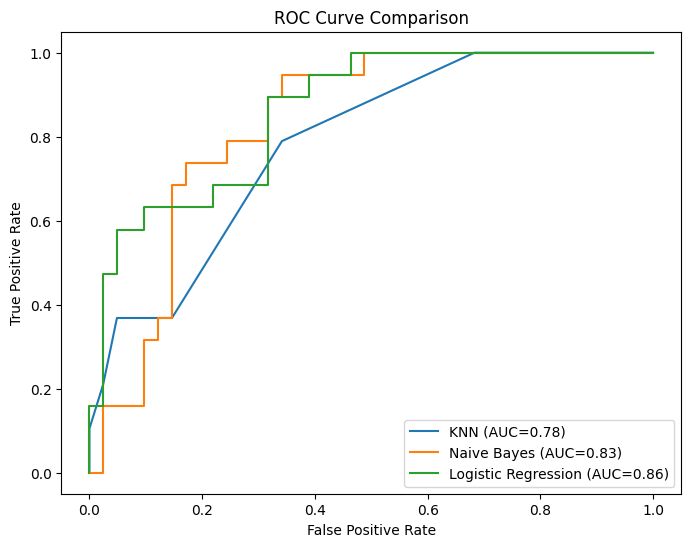

In [19]:
#Q : consider a dataset from kaggle and implement knn and naive base then compose
# its performance eith logistic regression model

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

df=pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')

x=df.drop('DEATH_EVENT',axis=1)
y=df['DEATH_EVENT']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn=knn.predict(x_test)

print("KNN Model Evaluation:")
print("Accuracy:",accuracy_score(y_test,y_pred_knn))
print("\nClassification Report:\n",classification_report(y_test,y_pred_knn))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))

nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb=nb.predict(x_test)

print("\nNaive Bayes Model Evaluation:")
print("Accuracy:",accuracy_score(y_test,y_pred_nb))
print("\nClassification Report:\n",classification_report(y_test,y_pred_nb))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred_nb))

# NOW COMPARE KNN AND NAIVE BIAS

print("KNN Accuracy:",accuracy_score(y_test,y_pred_knn))
print("Naive Bayes Accuracy:",accuracy_score(y_test,y_pred_nb))
for i in range(1,11):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred_knn=knn.predict(x_test)
  print(f"KNN Accuracy with k={i}:",accuracy_score(y_test,y_pred_knn))

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(random_state=42)
lr.fit(x_train,y_train)

knn_probs=knn.predict_proba(x_test)[:,1]
nb_probs=nb.predict_proba(x_test)[:,1]
lr_probs=lr.predict_proba(x_test)[:,1]

fpr_knn,tpr_knn,_=roc_curve(y_test,knn_probs)
fpr_nb,tpr_nb,_=roc_curve(y_test,nb_probs)
fpr_lr,tpr_lr,_=roc_curve(y_test,lr_probs)

auc_knn=auc(fpr_knn,tpr_knn)
auc_nb=auc(fpr_nb,tpr_nb)
auc_lr=auc(fpr_lr,tpr_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn,tpr_knn,label=f'KNN (AUC={auc_knn:.2f})')
plt.plot(fpr_nb,tpr_nb,label=f'Naive Bayes (AUC={auc_nb:.2f})')
plt.plot(fpr_lr,tpr_lr,label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot([0],[1],linestyle='--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()









